In [73]:
%matplotlib inline

In [74]:
from pandas import *
import numpy
import numpy as np
import matplotlib.pyplot as plt
from random import shuffle

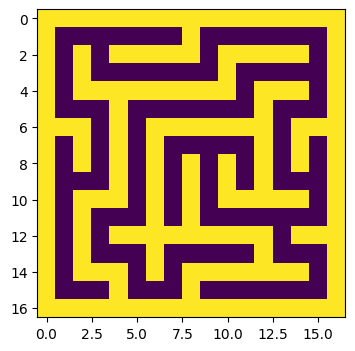

In [75]:
def make_maze(w , h):
    vis = [[0] * w + [1] for _ in range(h)] + [[1] * (w + 1)]
    ver = [["10"] * w + ['1'] for _ in range(h)] + [[]]
    hor = [["11"] * w + ['1'] for _ in range(h + 1)]
 
    def walk(x, y):
        vis[y][x] = 1
 
        d = [(x - 1, y), (x, y + 1), (x + 1, y), (x, y - 1)]
        shuffle(d)
        for (xx, yy) in d:
            if vis[yy][xx]: continue
            if xx == x: hor[max(y, yy)][x] = "10"
            if yy == y: ver[y][max(x, xx)] = "00"
            walk(xx, yy)
 
    walk(numpy.random.randint(w), numpy.random.randint(h))
 
    s = ""
    for (a, b) in zip(hor, ver):
        s += ''.join(a + ['\n'] + b + ['\n'])
        
    M=[]
    for line in s.split("\n"):
        if line!="":
            R=[]
            for e in line:
                R.append(int(e))
            M.append(R)
    return M

maze = np.array(make_maze(8, 8))

plt.figure(figsize=(4, 4))
plt.imshow(maze)   # or "gray"
plt.show()

In [84]:
import heapq
import numpy as np
import matplotlib.pyplot as plt


In [85]:
def heuristic(a, b):
    return np.sqrt((b[0] - a[0])**2 + (b[1] - a[1])**2)


In [86]:
def get_neighbors(node, maze):
    x, y = node
    neighbors = []
    directions = [(1,0), (-1,0), (0,1), (0,-1)]

    for dx, dy in directions:
        nx, ny = x + dx, y + dy
        if 0 <= nx < maze.shape[1] and 0 <= ny < maze.shape[0]:
            if maze[ny][nx] == 0:   # 0 = fri cell
                neighbors.append((nx, ny))
    return neighbors


In [87]:
def astar(maze, start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {start: 0}

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            # rekonstruera väg
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for neighbor in get_neighbors(current, maze):
            tentative_g = g_score[current] + 1

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f_score = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f_score, neighbor))

    return None  # ingen väg hittad


In [88]:
start = (1, 1)
goal = (15, 15)

path = astar(maze, start, goal)
print("Path length:", len(path))


Path length: 41


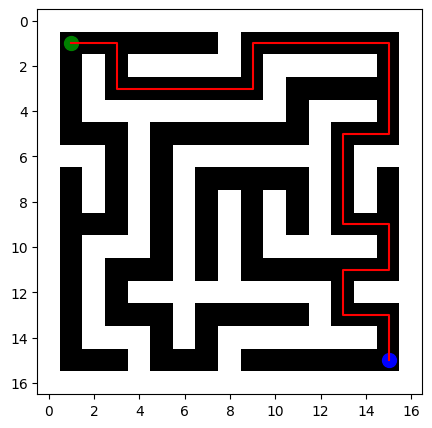

In [89]:
plt.figure(figsize=(5,5))
plt.imshow(maze, cmap="gray")

if path:
    xs = [p[0] for p in path]
    ys = [p[1] for p in path]
    plt.plot(xs, ys, 'r')

plt.scatter(start[0], start[1], c='green', s=100)
plt.scatter(goal[0], goal[1], c='blue', s=100)
plt.show()
